## Setup and preprocessing — GGG, fresh raw load

In [2]:
# Block 1 — Setup, imports, output folder, raw load, encoding, imd_band fix

import pandas as pd
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from dowhy import CausalModel
from econml.dml import CausalForestDML

OUTPUT_DIR = r"C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_PATH = r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\GGG.csv"
df = pd.read_csv(DATA_PATH)

df_sel = df.copy()

df_sel['imd_band'] = df_sel['imd_band'].replace('10-20', '10-20%')
imd_mode = df_sel['imd_band'].mode()[0]
df_sel['imd_band'] = df_sel['imd_band'].fillna(imd_mode)

final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
df_sel['final_result'] = df_sel['final_result'].map(final_result_map)

highest_education_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2,
    'HE Qualification': 3, 'Post Graduate Qualification': 4
}
df_sel['highest_education'] = df_sel['highest_education'].map(highest_education_map)

imd_band_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
df_sel['imd_band'] = df_sel['imd_band'].map(imd_band_map)

age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}
df_sel['age_band'] = df_sel['age_band'].map(age_band_map)

df_sel['gender'] = df_sel['gender'].map({'F': 0, 'M': 1})
df_sel['disability'] = df_sel['disability'].map({'N': 0, 'Y': 1})

le = LabelEncoder()
df_sel['region'] = le.fit_transform(df_sel['region'])

print(df_sel.shape)
print(df_sel.columns.tolist())

(2534, 38)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'ass_8_date', 'ass_8_score', 'ass_9_date', 'ass_9_score', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucontent', 'clicks_quiz', 'clicks_resource', 'clicks_subpage']


## Assessment binning, click variation check

In [5]:
# Block 2 — Assessment NaN->-1 + quartile bin, click variation check

assessment_cols = ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score',
                    'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score']
for col in assessment_cols:
    df_sel[col] = df_sel[col].fillna(-1)
    df_sel[col] = pd.qcut(df_sel[col], q=4, labels=False, duplicates='drop')

print("Assessment bin counts:")
for col in assessment_cols:
    print(col, df_sel[col].nunique(), "bins")

click_cols = ['clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucontent',
              'clicks_quiz', 'clicks_resource', 'clicks_subpage']
for col in click_cols:
    df_sel[col] = df_sel[col].fillna(0)

print("\nClick variation:")
for col in click_cols:
    nonzero = (df_sel[col] > 0).sum()
    unique_vals = df_sel[col].nunique()
    print(col, "nonzero:", nonzero, f"({round(nonzero/len(df_sel)*100,1)}%)", "| unique vals:", unique_vals)

Assessment bin counts:
ass_1_score 4 bins
ass_2_score 3 bins
ass_3_score 3 bins
ass_4_score 2 bins
ass_5_score 2 bins
ass_6_score 2 bins
ass_7_score 2 bins
ass_8_score 3 bins
ass_9_score 1 bins

Click variation:
clicks_forumng nonzero: 1892 (74.7%) | unique vals: 411
clicks_glossary nonzero: 1131 (44.6%) | unique vals: 67
clicks_homepage nonzero: 2364 (93.3%) | unique vals: 404
clicks_oucontent nonzero: 2277 (89.9%) | unique vals: 598
clicks_quiz nonzero: 1989 (78.5%) | unique vals: 248
clicks_resource nonzero: 2322 (91.6%) | unique vals: 166
clicks_subpage nonzero: 2280 (90.0%) | unique vals: 118


## total_clicks composite — sum raw clicks, quartile-bin, drop individual columns

In [8]:
# Block 3 — total_clicks composite

df_sel['total_clicks'] = df_sel[click_cols].sum(axis=1)
df_sel['total_clicks'] = pd.qcut(df_sel['total_clicks'], q=4, labels=False, duplicates='drop')

print(df_sel['total_clicks'].nunique(), "bins")
print(df_sel['total_clicks'].value_counts().sort_index())

df_sel_combined = df_sel.drop(columns=click_cols)
print(df_sel_combined.shape)

4 bins
total_clicks
0    634
1    633
2    634
3    633
Name: count, dtype: int64
(2534, 32)


## Final modeling variable set — drop identifiers and date columns

In [11]:
# Block 4 — Build df_model

date_cols = [c for c in df_sel_combined.columns if c.endswith('_date')] + ['date_registration', 'date_unregistration']
id_cols = ['code_presentation', 'id_student']

df_model = df_sel_combined.drop(columns=date_cols + id_cols)

print(df_model.shape)
print(df_model.columns.tolist())
print(df_model.dtypes)

(2534, 19)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'total_clicks']
gender                  int64
region                  int64
highest_education       int64
imd_band                int64
age_band                int64
num_of_prev_attempts    int64
studied_credits         int64
disability              int64
final_result            int64
ass_1_score             int64
ass_2_score             int64
ass_3_score             int64
ass_4_score             int64
ass_5_score             int64
ass_6_score             int64
ass_7_score             int64
ass_8_score             int64
ass_9_score             int64
total_clicks            int64
dtype: object


## Build GGG combined DAG in networkx, derive treatments and adjustment sets

In [14]:
# Block 5 — Build DiGraph, derive treatments and adjustment sets

edges = [
    ('imd_band', 'region'),
    ('disability', 'region'),
    ('age_band', 'highest_education'),
    ('disability', 'highest_education'),
    ('age_band', 'total_clicks'),
    ('ass_1_score', 'ass_2_score'),
    ('ass_1_score', 'ass_3_score'),
    ('ass_1_score', 'ass_4_score'),
    ('ass_1_score', 'final_result'),
    ('total_clicks', 'ass_1_score'),
    ('ass_2_score', 'ass_3_score'),
    ('ass_2_score', 'ass_4_score'),
    ('ass_2_score', 'ass_6_score'),
    ('ass_3_score', 'ass_5_score'),
    ('ass_3_score', 'final_result'),
    ('total_clicks', 'ass_3_score'),
    ('ass_4_score', 'ass_5_score'),
    ('ass_4_score', 'ass_7_score'),
    ('total_clicks', 'ass_4_score'),
    ('ass_5_score', 'ass_6_score'),
    ('ass_5_score', 'ass_7_score'),
    ('total_clicks', 'ass_5_score'),
    ('ass_6_score', 'final_result'),
    ('ass_7_score', 'ass_8_score'),
    ('ass_7_score', 'final_result'),
    ('total_clicks', 'ass_7_score'),
    ('ass_8_score', 'final_result'),
    ('total_clicks', 'ass_8_score'),
    ('total_clicks', 'final_result'),
]
undirected_pairs = [('num_of_prev_attempts', 'studied_credits')]

G = nx.DiGraph()
G.add_edges_from(edges)

treatments = [n for n in G.nodes() if n != 'final_result' and nx.has_path(G, n, 'final_result')]
print("Treatments:", treatments)

adjustment_sets = {t: list(G.predecessors(t)) for t in treatments}
for t, adj in adjustment_sets.items():
    print(t, "->", adj)

Treatments: ['age_band', 'total_clicks', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_6_score', 'ass_5_score', 'ass_7_score', 'ass_8_score']
age_band -> []
total_clicks -> ['age_band']
ass_1_score -> ['total_clicks']
ass_2_score -> ['ass_1_score']
ass_3_score -> ['ass_1_score', 'ass_2_score', 'total_clicks']
ass_4_score -> ['ass_1_score', 'ass_2_score', 'total_clicks']
ass_6_score -> ['ass_2_score', 'ass_5_score']
ass_5_score -> ['ass_3_score', 'ass_4_score', 'total_clicks']
ass_7_score -> ['ass_4_score', 'ass_5_score', 'total_clicks']
ass_8_score -> ['ass_7_score', 'total_clicks']


## DoWhy ATE loop — all 10 treatments, with 95% confidence intervals

In [17]:
# Block 6 — DoWhy ATE loop

results = []

for treatment in treatments:
    common_causes = adjustment_sets[treatment]

    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    results.append({
        'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

results_df = pd.DataFrame(results)
results_df

age_band: ATE=0.074, CI=[0.005, 0.144], significant=True
total_clicks: ATE=0.527, CI=[0.504, 0.551], significant=True
ass_1_score: ATE=0.164, CI=[0.138, 0.190], significant=True
ass_2_score: ATE=0.345, CI=[0.300, 0.389], significant=True
ass_3_score: ATE=0.319, CI=[0.276, 0.362], significant=True
ass_4_score: ATE=0.248, CI=[0.189, 0.307], significant=True
ass_6_score: ATE=0.455, CI=[0.390, 0.520], significant=True
ass_5_score: ATE=0.151, CI=[0.094, 0.208], significant=True
ass_7_score: ATE=0.475, CI=[0.413, 0.537], significant=True
ass_8_score: ATE=0.252, CI=[0.213, 0.290], significant=True


,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,age_band,[],0.074296,0.004695,0.143896,True
1,total_clicks,[age_band],0.527366,0.504034,0.550698,True
2,ass_1_score,[total_clicks],0.164105,0.138110,0.190100,True
3,ass_2_score,[ass_1_score],0.344514,0.300322,0.388705,True
4,ass_3_score,"[ass_1_score, ass_2_score, total_clicks]",0.318693,0.275659,0.361727,True
5,ass_4_score,"[ass_1_score, ass_2_score, total_clicks]",0.247989,0.189165,0.306813,True
6,ass_6_score,"[ass_2_score, ass_5_score]",0.454858,0.389551,0.520164,True
7,ass_5_score,"[ass_3_score, ass_4_score, total_clicks]",0.150737,0.093637,0.207837,True
8,ass_7_score,"[ass_4_score, ass_5_score, total_clicks]",0.474645,0.412563,0.536727,True
9,ass_8_score,"[ass_7_score, total_clicks]",0.251878,0.213489,0.290268,True


## Refutation — placebo treatment + random common cause, all 10 treatments

In [20]:
# Block 7 — Refutation loop

refutation_results = []

for treatment in treatments:
    common_causes = adjustment_sets[treatment]

    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    original_ate = estimate.value

    placebo_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter", placebo_type="permute"
    )
    random_cause_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="random_common_cause"
    )

    refutation_results.append({
        'treatment': treatment, 'original_ATE': original_ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_new_effect': random_cause_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - original_ate)
    })

    print(f"{treatment}: placebo_effect={placebo_refute.new_effect:.4f}, random_cause_effect={random_cause_refute.new_effect:.4f}")

refutation_df = pd.DataFrame(refutation_results)
refutation_df

age_band: placebo_effect=-0.0050, random_cause_effect=0.0742
total_clicks: placebo_effect=0.0011, random_cause_effect=0.5274
ass_1_score: placebo_effect=-0.0007, random_cause_effect=0.1641
ass_2_score: placebo_effect=-0.0014, random_cause_effect=0.3444
ass_3_score: placebo_effect=0.0021, random_cause_effect=0.3187
ass_4_score: placebo_effect=0.0045, random_cause_effect=0.2481
ass_6_score: placebo_effect=-0.0058, random_cause_effect=0.4549
ass_5_score: placebo_effect=0.0010, random_cause_effect=0.1507
ass_7_score: placebo_effect=0.0025, random_cause_effect=0.4747
ass_8_score: placebo_effect=-0.0003, random_cause_effect=0.2518


,treatment,original_ATE,placebo_new_effect,random_cause_new_effect,random_cause_diff
0,age_band,0.074296,-0.004983,0.074246,0.000050
1,total_clicks,0.527366,0.001116,0.527395,0.000029
2,ass_1_score,0.164105,-0.000723,0.164114,0.000009
3,ass_2_score,0.344514,-0.001448,0.344424,0.000090
4,ass_3_score,0.318693,0.002124,0.318695,0.000002
5,ass_4_score,0.247989,0.004461,0.248089,0.000099
6,ass_6_score,0.454858,-0.005815,0.454892,0.000034
7,ass_5_score,0.150737,0.001030,0.150679,0.000058
8,ass_7_score,0.474645,0.002496,0.474668,0.000024
9,ass_8_score,0.251878,-0.000344,0.251836,0.000042


## EconML CausalForestDML — CATE setup, age_band vs imd_band moderators

In [23]:
# Block 8 — CATE loop, all 10 treatments x 2 moderators

cate_results = []
moderators = ['age_band', 'imd_band']

for treatment in treatments:
    adj_set = adjustment_sets[treatment]

    for moderator in moderators:
        if treatment == moderator:
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_model[[moderator]].values
        T = df_model[treatment].values
        Y = df_model['final_result'].values
        W = df_model[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        cate_values = est.effect(X)

        cate_results.append({
            'treatment': treatment, 'moderator': moderator, 'W_cols': W_cols,
            'CATE_mean': cate_values.mean(), 'CATE_min': cate_values.min(),
            'CATE_max': cate_values.max(), 'CATE_std': cate_values.std()
        })

        print(f"{treatment} | moderator={moderator}: mean={cate_values.mean():.3f}, std={cate_values.std():.3f}")

cate_df = pd.DataFrame(cate_results)
cate_df

age_band | moderator=imd_band: mean=0.057, std=0.108
total_clicks | moderator=age_band: mean=0.526, std=0.003
total_clicks | moderator=imd_band: mean=0.523, std=0.036
ass_1_score | moderator=age_band: mean=0.127, std=0.012
ass_1_score | moderator=imd_band: mean=0.115, std=0.066
ass_2_score | moderator=age_band: mean=0.355, std=0.011
ass_2_score | moderator=imd_band: mean=0.356, std=0.089
ass_3_score | moderator=age_band: mean=0.309, std=0.004
ass_3_score | moderator=imd_band: mean=0.308, std=0.072
ass_4_score | moderator=age_band: mean=0.249, std=0.020
ass_4_score | moderator=imd_band: mean=0.245, std=0.127
ass_6_score | moderator=age_band: mean=0.402, std=0.011
ass_6_score | moderator=imd_band: mean=0.396, std=0.097
ass_5_score | moderator=age_band: mean=0.125, std=0.061
ass_5_score | moderator=imd_band: mean=0.152, std=0.070
ass_7_score | moderator=age_band: mean=0.420, std=0.011
ass_7_score | moderator=imd_band: mean=0.465, std=0.081
ass_8_score | moderator=age_band: mean=0.218, std

,treatment,moderator,W_cols,CATE_mean,CATE_min,CATE_max,CATE_std
0,age_band,imd_band,[],0.056948,-0.126869,0.235715,0.108080
1,total_clicks,age_band,[],0.525876,0.521708,0.528535,0.003329
2,total_clicks,imd_band,[age_band],0.522607,0.467976,0.592186,0.036003
3,ass_1_score,age_band,[total_clicks],0.126706,0.112018,0.136077,0.011732
4,ass_1_score,imd_band,[total_clicks],0.114894,-0.048412,0.174474,0.065560
5,ass_2_score,age_band,[ass_1_score],0.355221,0.346399,0.369050,0.011045
6,ass_2_score,imd_band,[ass_1_score],0.355589,0.208384,0.500867,0.089452
7,ass_3_score,age_band,"[ass_1_score, ass_2_score, total_clicks]",0.308504,0.305656,0.312968,0.003565
8,ass_3_score,imd_band,"[ass_1_score, ass_2_score, total_clicks]",0.307922,0.206640,0.459128,0.071858
9,ass_4_score,age_band,"[ass_1_score, ass_2_score, total_clicks]",0.249426,0.224464,0.265352,0.019938


## CATE point + 95% CI plots by moderator bin — looped, saved per treatment

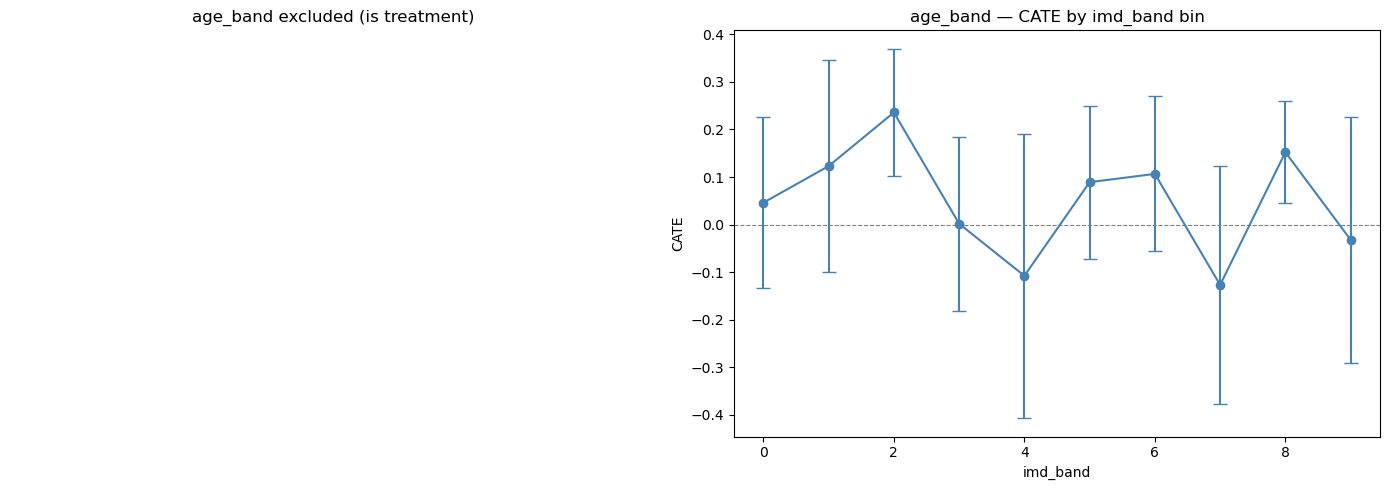

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_CATE_age_band.png


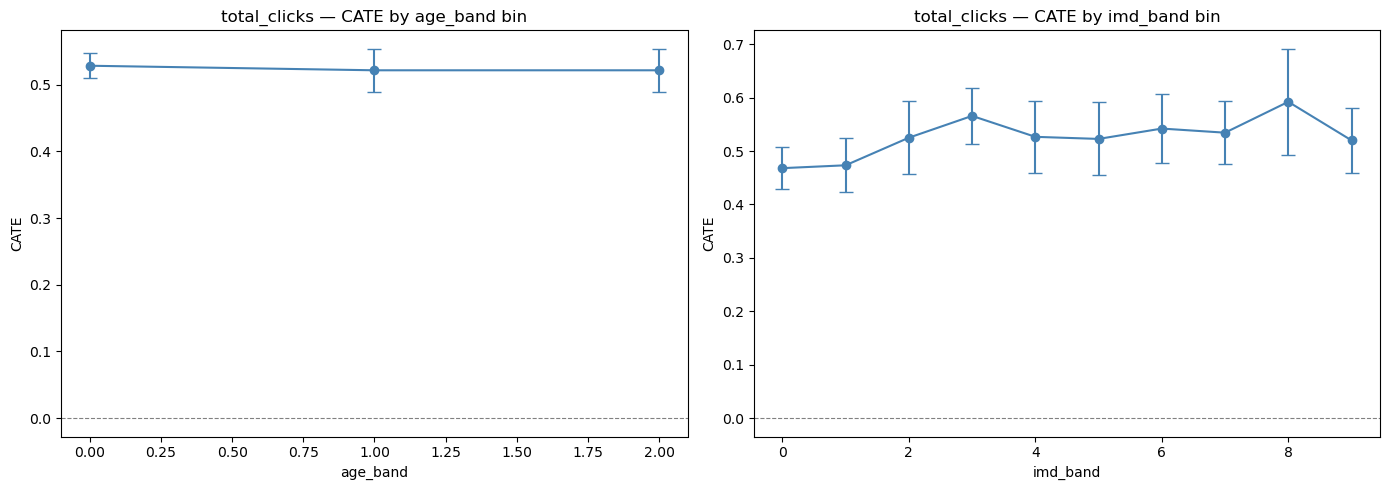

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_CATE_total_clicks.png


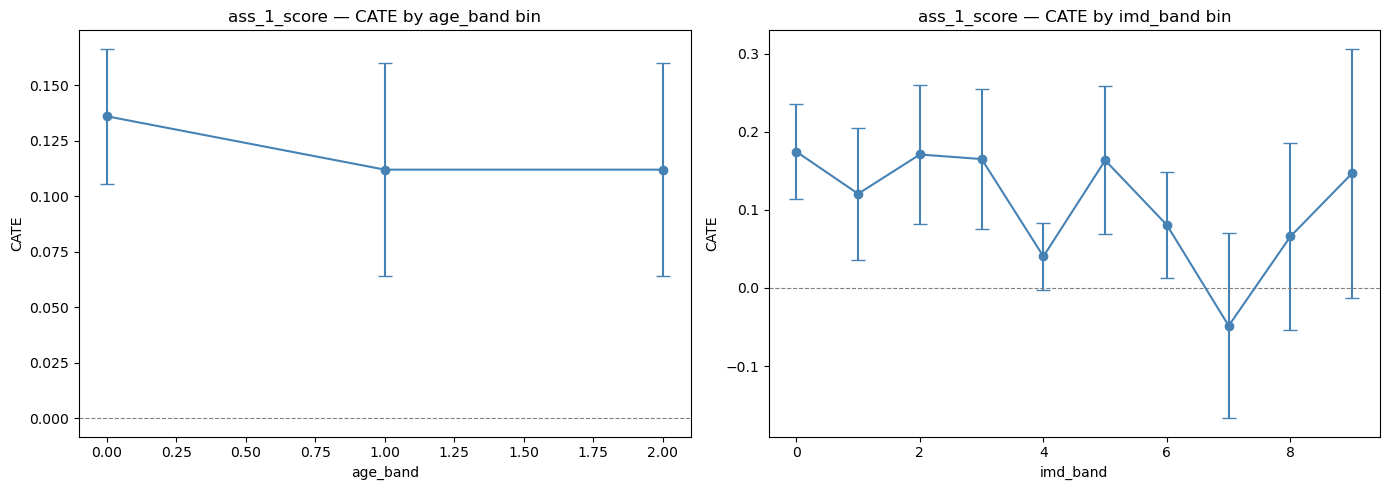

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_CATE_ass_1_score.png


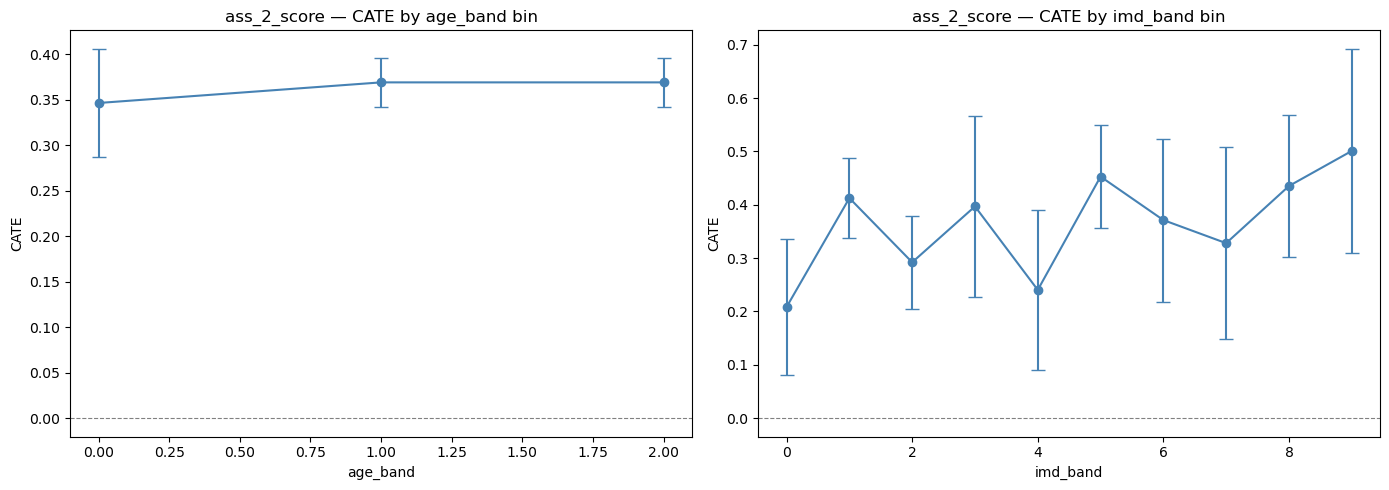

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_CATE_ass_2_score.png


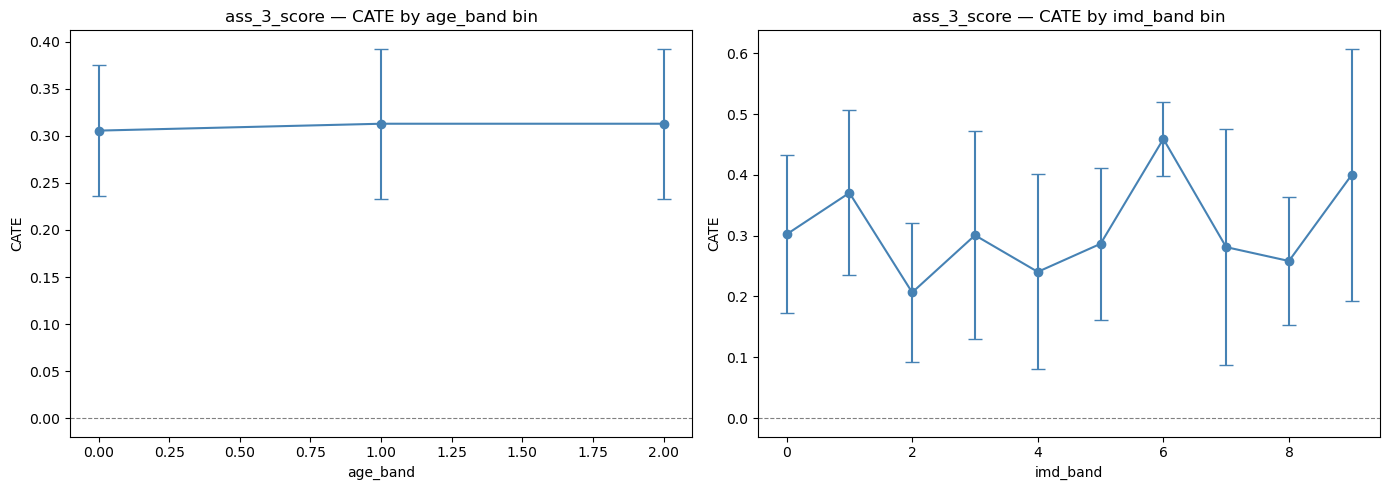

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_CATE_ass_3_score.png


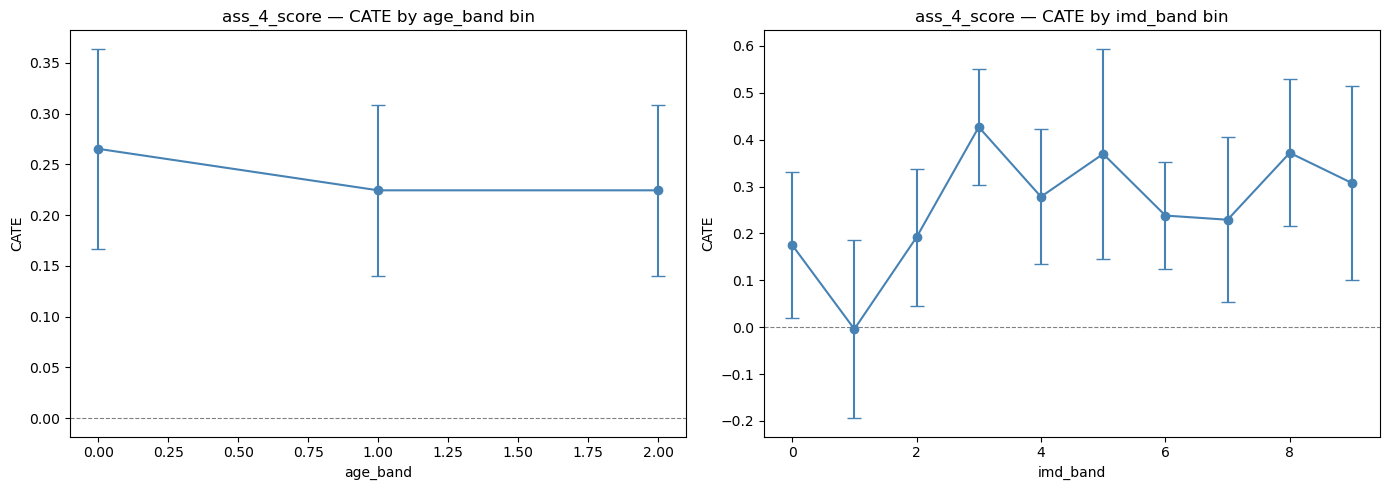

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_CATE_ass_4_score.png


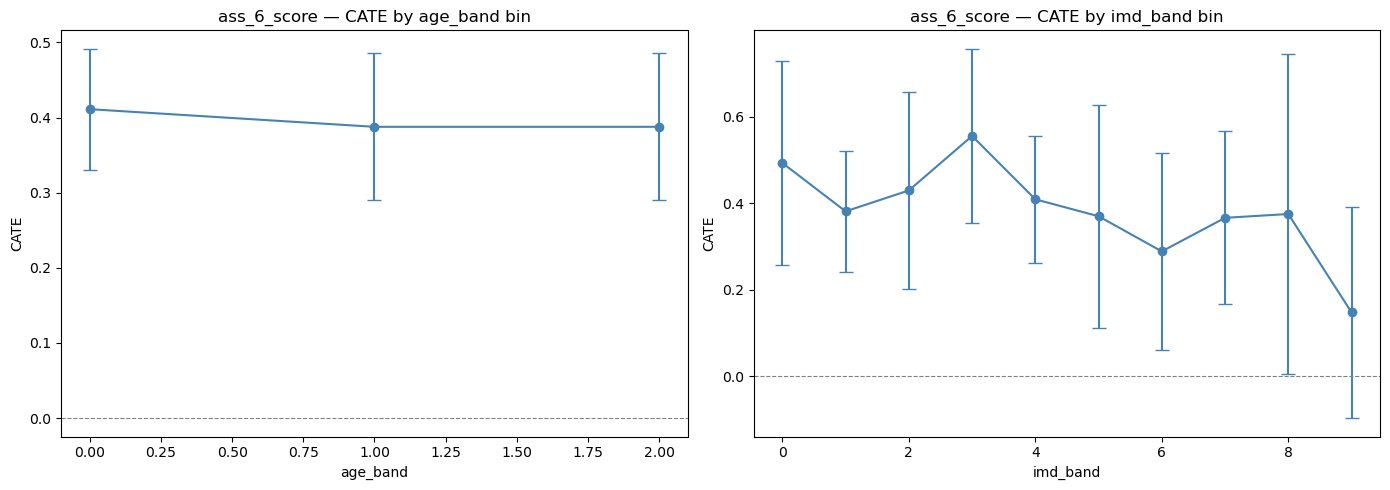

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_CATE_ass_6_score.png


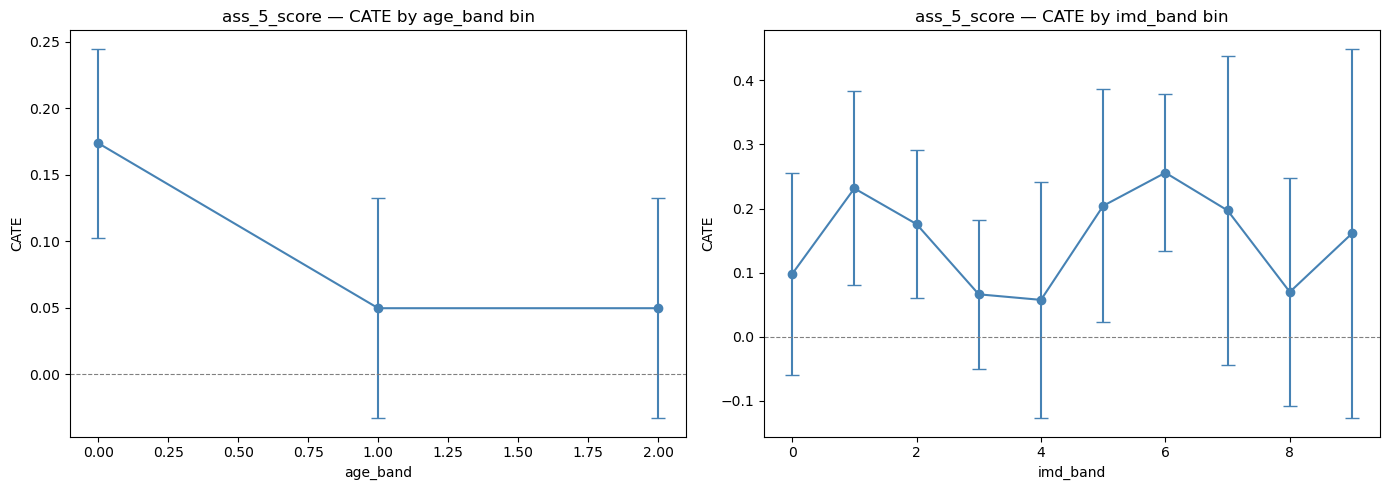

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_CATE_ass_5_score.png


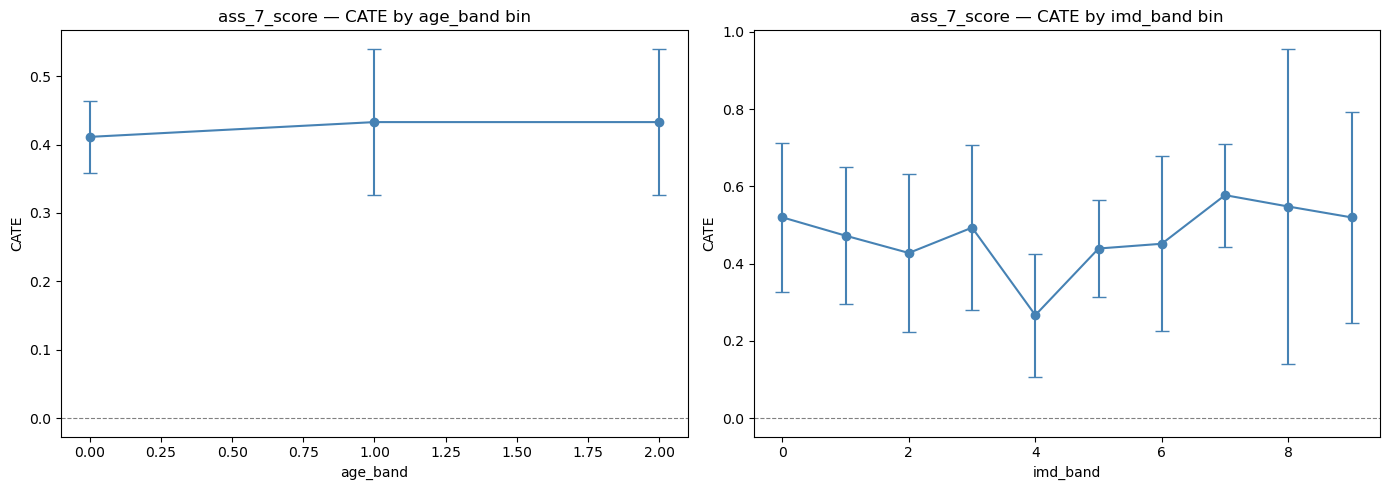

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_CATE_ass_7_score.png


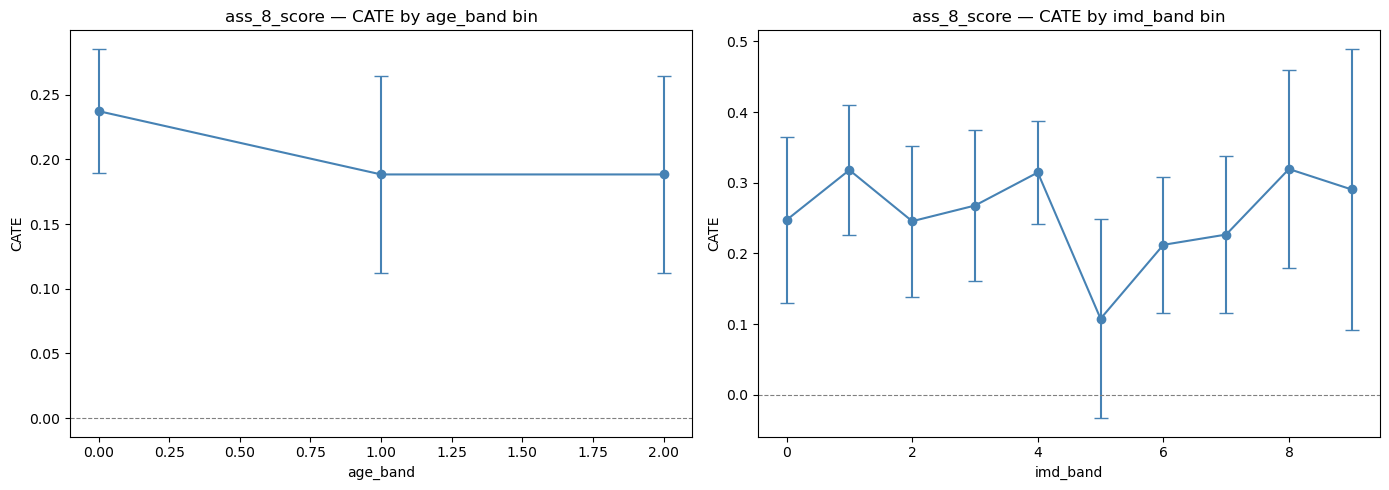

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_CATE_ass_8_score.png


In [26]:
# Block 9 — CATE point + CI plots

for treatment in treatments:
    adj_set = adjustment_sets[treatment]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, moderator in zip(axes, moderators):
        if treatment == moderator:
            ax.axis('off')
            ax.set_title(f"{moderator} excluded (is treatment)")
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_model[[moderator]].values
        T = df_model[treatment].values
        Y = df_model['final_result'].values
        W = df_model[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        bin_values = sorted(df_model[moderator].unique())
        X_bins = np.array(bin_values).reshape(-1, 1)

        point_estimates = est.effect(X_bins)
        lb, ub = est.effect_interval(X_bins, alpha=0.05)
        yerr = np.array([point_estimates - lb, ub - point_estimates])

        ax.errorbar(bin_values, point_estimates, yerr=yerr, fmt='o-', capsize=5, color='steelblue')
        ax.set_xlabel(moderator)
        ax.set_ylabel('CATE')
        ax.set_title(f'{treatment} — CATE by {moderator} bin')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"GGG_CATE_{treatment}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## Policy tree — total_clicks only, both moderators, cost=0 (illustrative)

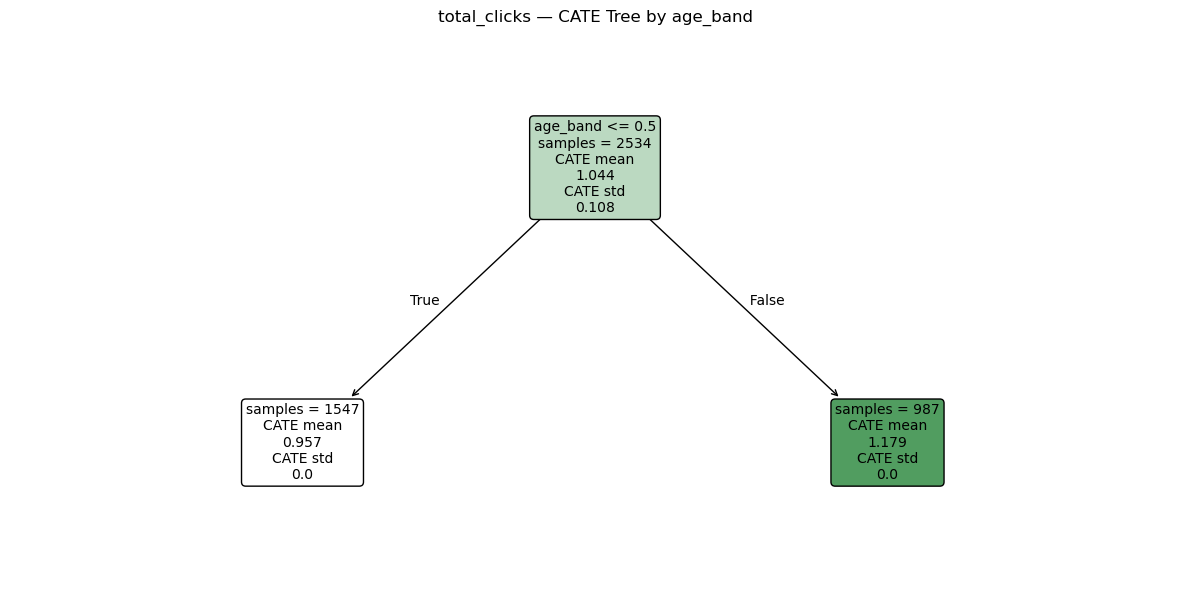

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_CATEtree_total_clicks_age_band.png


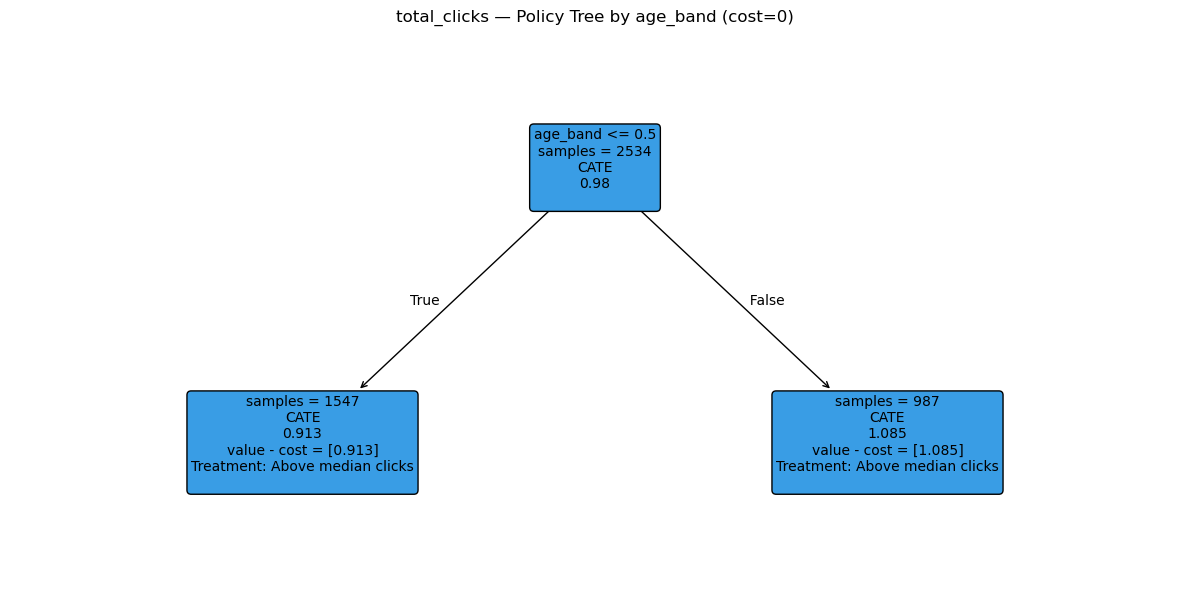

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_policytree_total_clicks_age_band.png


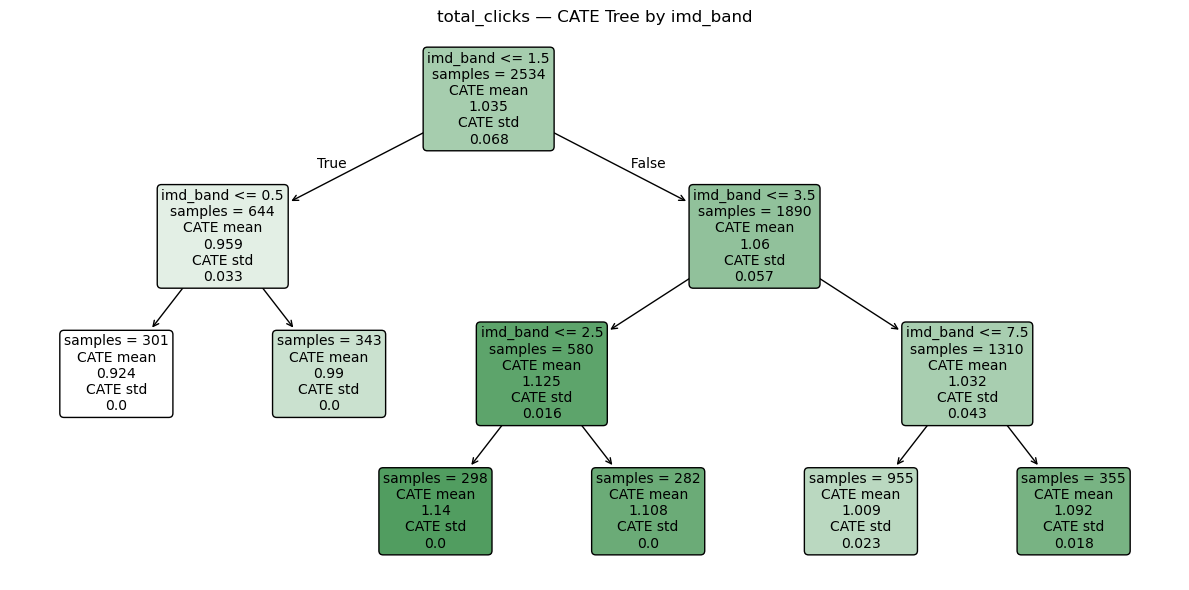

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_CATEtree_total_clicks_imd_band.png


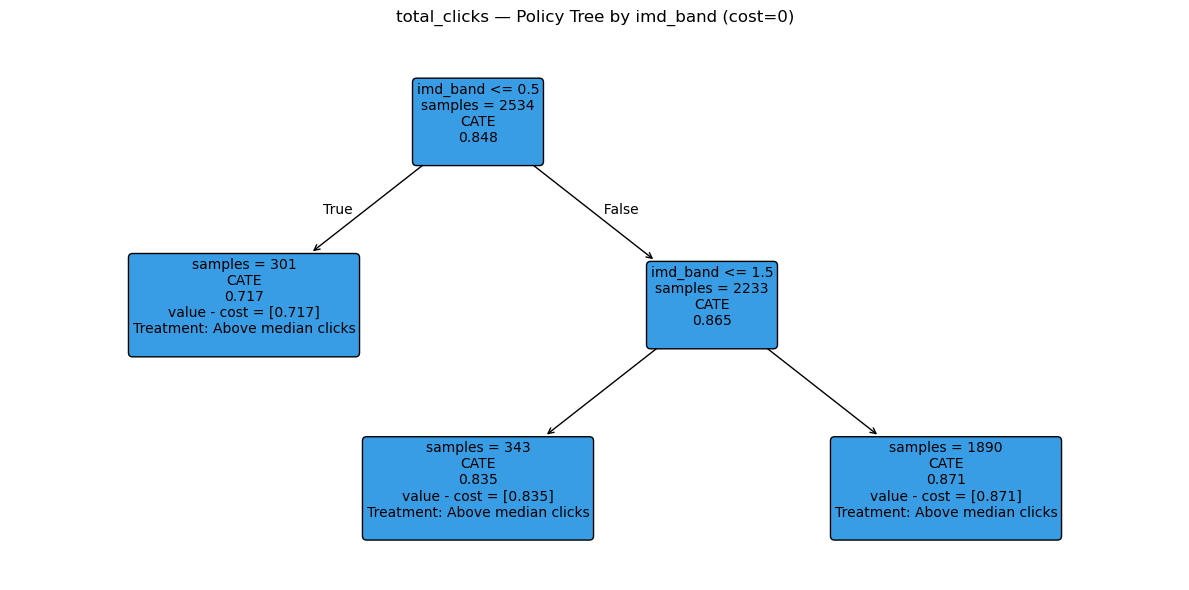

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_policytree_total_clicks_imd_band.png


In [29]:
# Block 10 — Policy tree restricted to total_clicks, both moderators, cost=0

from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter

treatment = 'total_clicks'
adj_set = adjustment_sets[treatment]

for moderator in moderators:
    W_cols = [c for c in adj_set if c != moderator]

    X = df_model[[moderator]].values
    T_binary = (df_model[treatment] >= df_model[treatment].median()).astype(int).values
    Y = df_model['final_result'].values
    W = df_model[W_cols].values if len(W_cols) > 0 else None

    est = CausalForestDML(random_state=42)
    est.fit(Y, T_binary, X=X, W=W)

    cate_interpreter = SingleTreeCateInterpreter(include_model_uncertainty=False, max_depth=3)
    cate_interpreter.interpret(est, X)

    plt.figure(figsize=(12, 6))
    cate_interpreter.plot(feature_names=[moderator], fontsize=10)
    plt.title(f'total_clicks — CATE Tree by {moderator}')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"GGG_CATEtree_total_clicks_{moderator}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

    policy_interpreter = SingleTreePolicyInterpreter(risk_level=0.05, max_depth=3, min_samples_leaf=30)
    policy_interpreter.interpret(est, X, sample_treatment_costs=0)

    plt.figure(figsize=(12, 6))
    policy_interpreter.plot(feature_names=[moderator], treatment_names=['Below median clicks', 'Above median clicks'], fontsize=10)
    plt.title(f'total_clicks — Policy Tree by {moderator} (cost=0)')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"GGG_policytree_total_clicks_{moderator}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## ATE heatmap

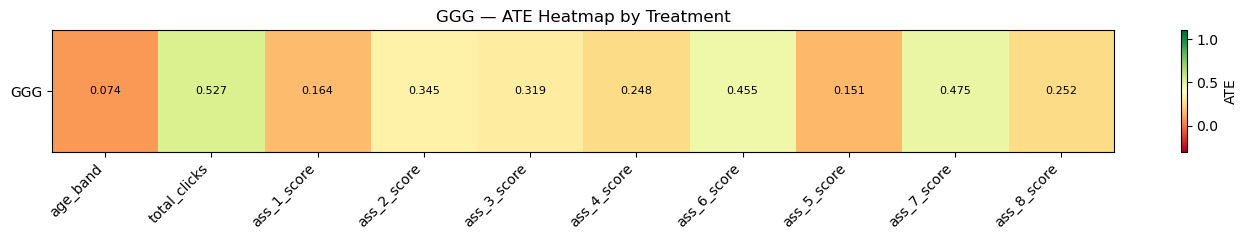

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_ATE_heatmap.png


In [34]:
# Block 11 — ATE heatmap, single row for GGG

heatmap_data = results_df.set_index('treatment')[['ATE']].T

plt.figure(figsize=(14, 2.5))
plt.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-0.3, vmax=1.1)
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha='right')
plt.yticks([0], ['GGG'])
plt.colorbar(label='ATE')

for i, val in enumerate(heatmap_data.values[0]):
    plt.text(i, 0, f'{val:.3f}', ha='center', va='center', fontsize=8)

plt.title('GGG — ATE Heatmap by Treatment')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "GGG_ATE_heatmap.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")

## DAG with ATE node overlay

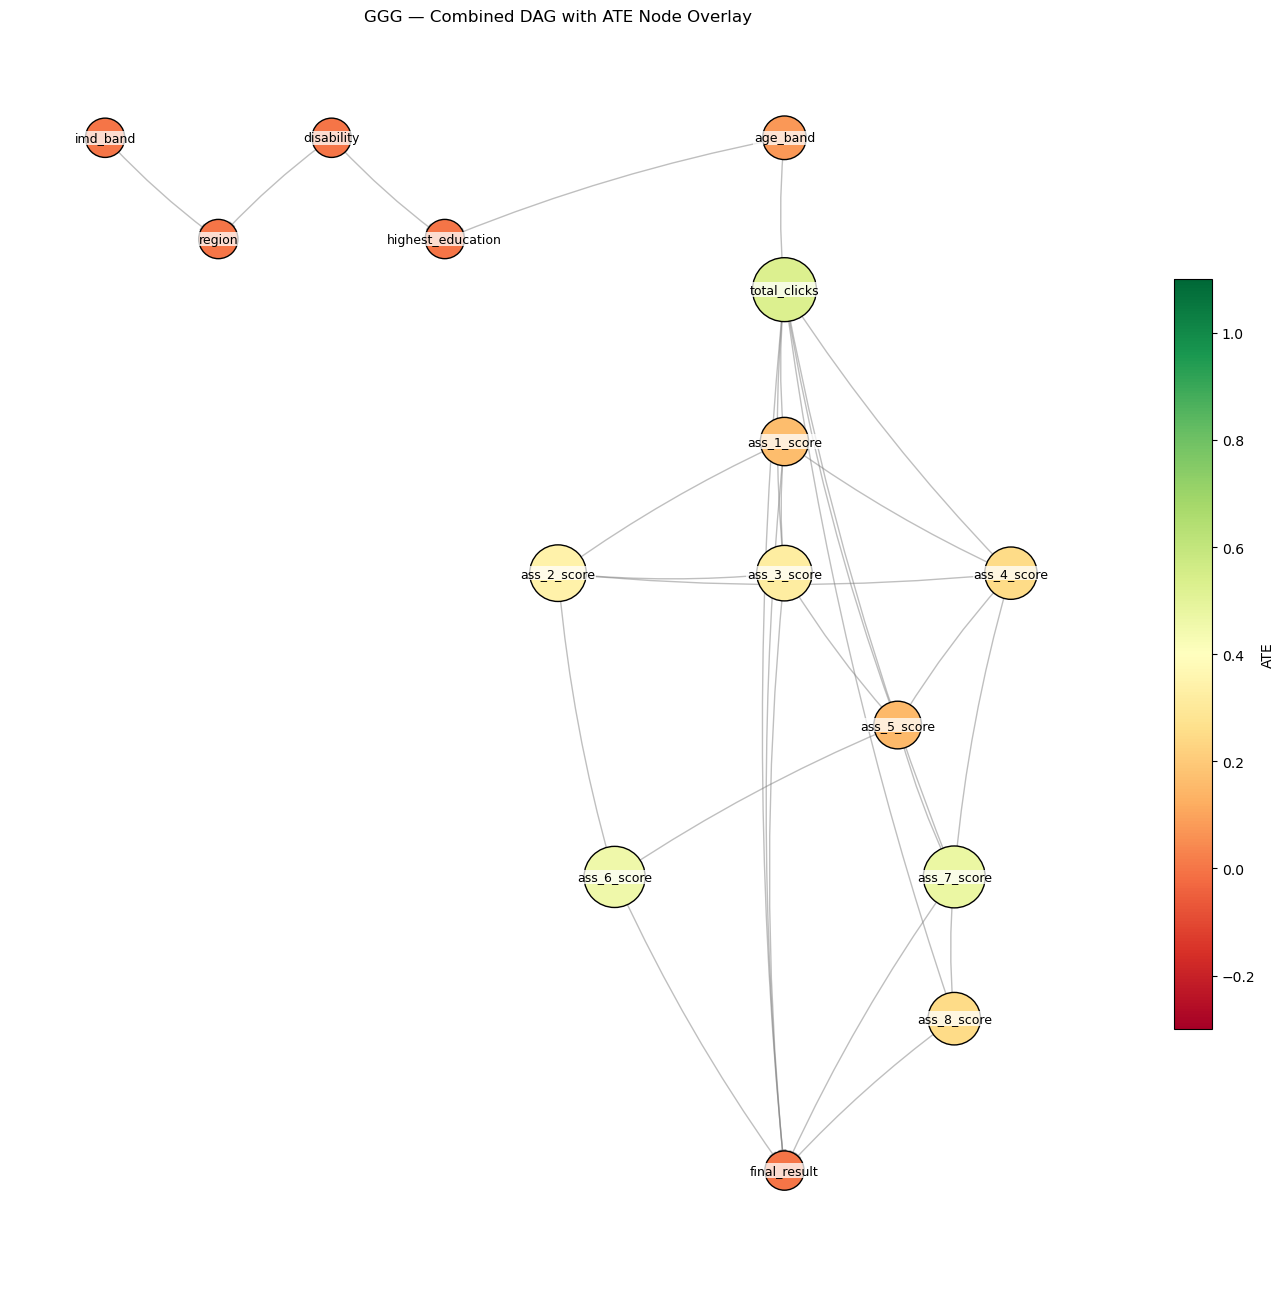

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\GGG\GGG_DAG_with_ATE.png


In [37]:
# Block 12 — DAG with ATE node overlay, manual fixed-position layout (branching structure)

pos = {
    # Dead-end demographic cluster (walled off from final_result)
    'imd_band': (0, 9),
    'disability': (2, 9),
    'region': (1, 8),
    'highest_education': (3, 8),

    # Sole surviving demographic path
    'age_band': (6, 9),
    'total_clicks': (6, 7.5),

    # Assessment cascade (branching)
    'ass_1_score': (6, 6),
    'ass_2_score': (4, 4.7),
    'ass_3_score': (6, 4.7),
    'ass_4_score': (8, 4.7),
    'ass_5_score': (7, 3.2),
    'ass_6_score': (4.5, 1.7),
    'ass_7_score': (7.5, 1.7),
    'ass_8_score': (7.5, 0.3),

    'final_result': (6, -1.2),
}

ate_lookup = results_df.set_index('treatment')['ATE'].to_dict()

fig, ax = plt.subplots(figsize=(14, 13))

node_colors, node_sizes = [], []
for node in G.nodes():
    ate_val = ate_lookup.get(node, 0)
    node_colors.append(ate_val)
    node_sizes.append(800 + abs(ate_val) * 2500)

missing_pos = [n for n in G.nodes() if n not in pos]
if missing_pos:
    print("WARNING — missing pos for:", missing_pos)

nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', arrows=True, arrowsize=12, alpha=0.5, connectionstyle='arc3,rad=0.05')
nc = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                             cmap='RdYlGn', vmin=-0.3, vmax=1.1, edgecolors='black')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9,
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.5))

cbar = plt.colorbar(nc, ax=ax, shrink=0.6)
cbar.set_label('ATE')

plt.title('GGG — Combined DAG with ATE Node Overlay')
plt.axis('off')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "GGG_DAG_with_ATE.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")